# Fase 2 & 3: Determinación de K y Modelado de Clustering

**Project Terra** — Descubrimiento de ecorregiones agrícolas con aprendizaje no supervisado.

En este notebook:
1. Evaluamos el número óptimo de clústeres ($K$) usando **Método del Codo (Inercia)**, **Coeficiente de Silueta** e **Índice de Davies-Bouldin**.
2. Entrenamos **K-Means** sobre los 7 atributos edafoclimáticos escalados (**el clustering NO se hace sobre PCA**).
3. Proyectamos los clústeres en 2D usando **PCA únicamente con propósitos de visualización interactiva**.
4. Contrastamos las agrupaciones con **Clustering Jerárquico Aglomerativo (Ward)** y dendrograma.
5. Exportamos el dataset enriquecido con las etiquetas de clúster a `data/processed/sensor_Crop_Dataset_clustered.csv`.


In [1]:
from IPython.display import display
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import plotly.express as px
import joblib

# Incorporar ruta raíz para importar módulos de src
ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from src.clustering import find_optimal_k, run_kmeans, compute_hierarchical_linkage, run_hierarchical
from src.profiling import plot_pca_clusters

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 1. Carga de Datos
Cargamos los datos limpios y las variables edafoclimáticas escaladas.


In [2]:
raw_path = ROOT_DIR / 'data' / 'raw' / 'sensor_Crop_Dataset.csv'
df = pd.read_csv(raw_path)
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

feature_cols = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']
X = df[feature_cols].values

# Escalado de variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
df_scaled.head()


Dataset cargado: 20,000 filas x 10 columnas


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
0,-0.194526,0.263243,1.267102,-1.014884,0.398209,-1.613560,0.835917
1,0.719418,0.920005,-0.888844,-0.556909,1.706133,-1.500767,-1.061136
2,1.276206,0.802154,-1.034668,0.582042,0.822224,0.060466,-1.162575
3,-1.482386,1.627335,-1.572150,-1.301155,-0.278378,-0.172904,-1.636999
4,-1.322013,1.699590,-0.628804,-1.063698,-0.678517,1.533371,0.766203


## 2. Determinación de K Óptimo
Evaluamos K entre 2 y 8 utilizando 3 criterios complementarios:
- **Inercia (Elbow Method):** Mide la suma de distancias al cuadrado intra-clúster.
- **Silhouette Score:** Mide qué tan similar es un punto a su propio clúster en comparación con otros (mayor es mejor).
- **Davies-Bouldin Index:** Mide la similitud entre cada clúster y su más parecido (menor es mejor).


c:\Users\darye\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\darye\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\darye\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\darye\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\darye\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _wina

,k,inertia,silhouette,davies_bouldin
0,2,124895.462512,0.107684,2.827068
1,3,115714.942484,0.093763,2.490192
2,4,108372.864868,0.098616,2.389747
3,5,102840.399765,0.098554,2.149006
4,6,98222.958366,0.099379,1.984155
5,7,93815.230212,0.102908,1.882414
6,8,90020.902265,0.104511,1.777932


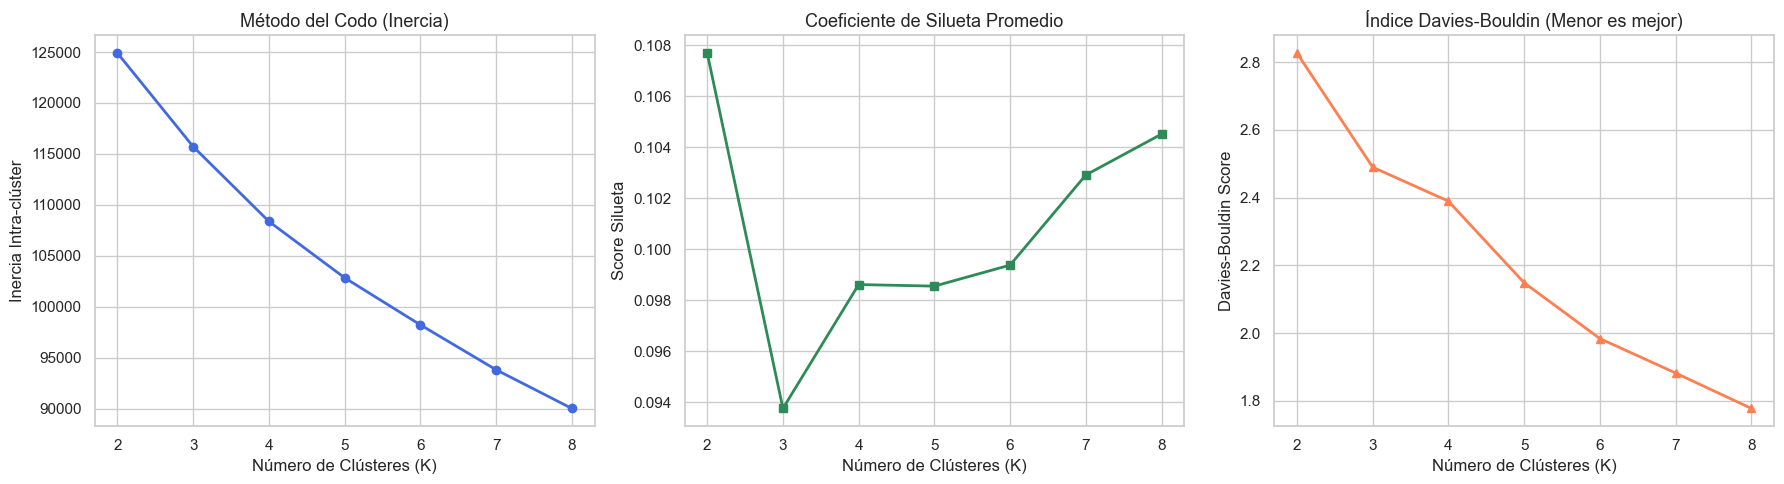

In [3]:
metrics_df = find_optimal_k(X_scaled, k_range=range(2, 9), random_state=42)
print(metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Inercia
axes[0].plot(metrics_df['k'], metrics_df['inertia'], marker='o', color='royalblue', linewidth=2)
axes[0].set_title('Método del Codo (Inercia)', fontsize=13)
axes[0].set_xlabel('Número de Clústeres (K)')
axes[0].set_ylabel('Inercia Intra-clúster')
axes[0].grid(True)

# 2. Silueta
axes[1].plot(metrics_df['k'], metrics_df['silhouette'], marker='s', color='seagreen', linewidth=2)
axes[1].set_title('Coeficiente de Silueta Promedio', fontsize=13)
axes[1].set_xlabel('Número de Clústeres (K)')
axes[1].set_ylabel('Score Silueta')
axes[1].grid(True)

# 3. Davies-Bouldin
axes[2].plot(metrics_df['k'], metrics_df['davies_bouldin'], marker='^', color='coral', linewidth=2)
axes[2].set_title('Índice Davies-Bouldin (Menor es mejor)', fontsize=13)
axes[2].set_xlabel('Número de Clústeres (K)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].grid(True)

plt.tight_layout()
plt.show()


## 3. Ajuste del Modelo K-Means ($K=5$)
Ajustamos el modelo K-Means sobre las 7 variables escaladas y guardamos los centroides.


In [4]:
k_optimal = 5
kmeans_labels, kmeans_model = run_kmeans(X_scaled, k=k_optimal, random_state=42)

# Inspección de centroides en escala original
centroids_scaled = kmeans_model.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=feature_cols)
centroids_df.index = [f'Ecorregión {i}' for i in range(k_optimal)]
print('Centroides de las Ecorregiones en escala real:')
print(centroids_df.round(2))


Centroides de las Ecorregiones en escala real:


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
Ecorregión 0,78.92,47.55,53.70,27.33,46.88,5.37,242.52
Ecorregión 1,75.32,49.74,79.41,28.52,82.46,6.23,245.35
Ecorregión 2,76.86,47.11,42.38,27.75,60.64,7.54,310.25
Ecorregión 3,78.86,46.07,32.37,26.90,81.27,6.11,146.04
Ecorregión 4,76.23,46.76,65.54,26.54,52.32,7.30,112.06


## 4. Visualización de Clústeres con PCA 2D
> **Nota metodológica crucial:** Como se determinó en la planificación, **el clustering se ejecutó sobre las 7 variables escaladas reales**. Usamos PCA en esta celda únicamente como técnica de proyección geométrica para graficar la distribución multivariada en dos dimensiones.


In [5]:
hover_info = df[['Crop', 'Soil_Type', 'Rainfall', 'Temperature']]
fig_pca, pca_obj = plot_pca_clusters(
    X_scaled=X_scaled,
    labels=kmeans_labels,
    hover_df=hover_info,
    sample_size=3000,
    title='Proyección PCA 2D de las Ecorregiones K-Means'
)
fig_pca.show()


## 5. Clustering Jerárquico Aglomerativo (Ward)
Generamos un dendrograma sobre una muestra representativa para observar la jerarquía de agrupamiento natural y comparamos las asignaciones de K-Means vs Jerárquico.


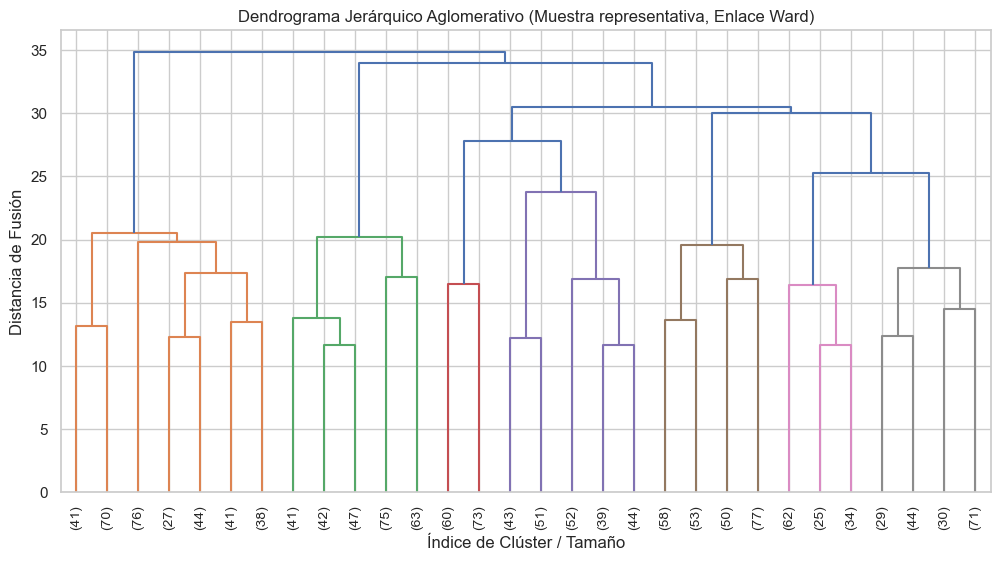

Tabla de Contingencia: K-Means vs. Clustering Jerárquico:


Jerárquico,0,1,2,3,4
K-Means,,,,,
0,1825,804,206,130,1062
1,132,1178,2269,468,201
2,783,1654,1079,64,236
3,726,583,1089,1512,16
4,1926,427,413,409,808


In [6]:
linkage_matrix = compute_hierarchical_linkage(X_scaled, method='ward', sample_size=1500, random_state=42)

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, show_leaf_counts=True, leaf_rotation=90)
plt.title('Dendrograma Jerárquico Aglomerativo (Muestra representativa, Enlace Ward)')
plt.xlabel('Índice de Clúster / Tamaño')
plt.ylabel('Distancia de Fusión')
plt.show()

# Ajuste jerárquico
hier_labels, _ = run_hierarchical(X_scaled, k=k_optimal, linkage_method='ward')

# Comparación K-Means vs Jerárquico
comparison = pd.crosstab(kmeans_labels, hier_labels, rownames=['K-Means'], colnames=['Jerárquico'])
print('Tabla de Contingencia: K-Means vs. Clustering Jerárquico:')
print(comparison)


## 6. Exportación del Dataset Enriquecido
Agregamos las columnas `kmeans_cluster` y `hierarchical_cluster` al DataFrame y lo guardamos en `data/processed/`.


In [7]:
df['kmeans_cluster'] = kmeans_labels
df['hierarchical_cluster'] = hier_labels

out_path = ROOT_DIR / 'data' / 'processed' / 'sensor_Crop_Dataset_clustered.csv'
df.to_csv(out_path, index=False)
print(f'Dataset exportado exitosamente en: {out_path}')

# Guardar también el modelo y el escalador para la app interactiva
models_dir = ROOT_DIR / 'data' / 'models'
models_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(kmeans_model, models_dir / f'kmeans_k{k_optimal}.joblib')
joblib.dump(scaler, models_dir / 'scaler.joblib')
print('Modelo y scaler serializados para la app Streamlit.')


Dataset exportado exitosamente en: c:\Users\darye\Desktop\Repos Git\Project_Terra\data\processed\sensor_Crop_Dataset_clustered.csv
Modelo y scaler serializados para la app Streamlit.


## 7. Gaussian Mixture Models (GMM) — Comparación con K-Means

> **¿Por qué GMM?**  
> K-Means asume clústeres esféricos de igual varianza y hace una asignación *hard*.  
> GMM modela cada clúster como una gaussiana multivariada, permitiendo:
> - Clústeres **elípticos** (mayor flexibilidad para datos agronómicos correlacionados)
> - Asignación **probabilística**: probabilidad de pertenecer a cada ecorregión
> - Selección de K mediante **BIC/AIC** (criterios estadísticos formales)

La comparación usa las **mismas 7 variables** escaladas y **K=2–10**.

In [8]:
from src.clustering import find_optimal_gmm, run_gmm, compare_models
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

COVARIANCE_TYPES = ('full', 'tied', 'diag', 'spherical')
K_RANGE = range(2, 11)

print('Ejecutando busqueda GMM (K=2..10, 4 tipos de covarianza)...')
print('Esto puede tardar 1-2 minutos...')
gmm_search_df = find_optimal_gmm(
    X_scaled,
    k_range=K_RANGE,
    covariance_types=COVARIANCE_TYPES,
    random_state=42,
    n_init=5,
)
print('Busqueda completa. Shape:', gmm_search_df.shape)
print(gmm_search_df.sort_values(['covariance_type', 'k']).round(2))

Ejecutando busqueda GMM (K=2..10, 4 tipos de covarianza)...
Esto puede tardar 1-2 minutos...
Busqueda completa. Shape: (36, 7)


,k,covariance_type,bic,aic,log_likelihood,silhouette,converged
18,2,diag,394462.35,394233.14,-197087.57,0.11,True
19,3,diag,392623.91,392276.16,-196094.08,0.09,True
20,4,diag,391368.07,390901.76,-195391.88,0.09,True
21,5,diag,390031.54,389446.68,-194649.34,0.08,True
22,6,diag,388981.03,388277.61,-194049.81,0.08,True
23,7,diag,387193.46,386371.50,-193081.75,0.06,True
24,8,diag,385543.10,384602.58,-192182.29,0.05,True
25,9,diag,385818.19,384759.12,-192245.56,0.04,True
26,10,diag,384971.12,383793.50,-191747.75,0.04,True
0,2,full,394848.45,394287.30,-197072.65,0.11,True


### 7.1 Curvas BIC y AIC por Tipo de Covarianza

El **BIC mínimo** indica el K óptimo para GMM.

In [9]:
fig_bic_aic = make_subplots(
    rows=1, cols=2,
    subplot_titles=['BIC por Tipo de Covarianza', 'AIC por Tipo de Covarianza'],
)
colors_cov = px.colors.qualitative.Set2
for i, cov in enumerate(COVARIANCE_TYPES):
    subset = gmm_search_df[gmm_search_df['covariance_type'] == cov].sort_values('k')
    color = colors_cov[i % len(colors_cov)]
    fig_bic_aic.add_trace(
        go.Scatter(x=subset['k'], y=subset['bic'], mode='lines+markers',
                   name=cov, line=dict(color=color, width=2),
                   marker=dict(size=7), legendgroup=cov),
        row=1, col=1,
    )
    fig_bic_aic.add_trace(
        go.Scatter(x=subset['k'], y=subset['aic'], mode='lines+markers',
                   name=cov, line=dict(color=color, width=2, dash='dash'),
                   marker=dict(size=7), showlegend=False, legendgroup=cov),
        row=1, col=2,
    )
fig_bic_aic.update_layout(
    title='Criterios de Seleccion de K para GMM',
    template='plotly_white', height=420, legend_title='Covarianza',
    margin=dict(l=40, r=40, t=70, b=40),
)
fig_bic_aic.update_xaxes(title_text='Numero de Componentes (K)', dtick=1)
fig_bic_aic.update_yaxes(title_text='BIC', row=1, col=1)
fig_bic_aic.update_yaxes(title_text='AIC', row=1, col=2)
fig_bic_aic.show()

### 7.2 Heatmap de BIC — K × Tipo de Covarianza

Celda verde = menor BIC = mejor combinación.

In [10]:
import numpy as np
bic_pivot = gmm_search_df.pivot(index='covariance_type', columns='k', values='bic')
fig_hm = go.Figure(go.Heatmap(
    z=bic_pivot.values,
    x=[str(k) for k in bic_pivot.columns],
    y=bic_pivot.index.tolist(),
    colorscale='RdYlGn_r',
    text=bic_pivot.values.round(0).astype(int),
    texttemplate='%{text}',
    colorbar=dict(title='BIC'),
    hovertemplate='K=%{x}<br>Cov=%{y}<br>BIC=%{z:.0f}<extra></extra>',
))
min_idx = np.unravel_index(np.argmin(bic_pivot.values), bic_pivot.values.shape)
best_cov = bic_pivot.index[min_idx[0]]
best_k_bic = int(bic_pivot.columns[min_idx[1]])
fig_hm.add_annotation(x=str(best_k_bic), y=best_cov,
    text='MIN', showarrow=False, font=dict(color='white', size=13))
fig_hm.update_layout(
    title=f'Heatmap BIC -- Mejor: K={best_k_bic}, cov={best_cov}',
    xaxis_title='K', yaxis_title='Covarianza',
    template='plotly_white', height=350,
    margin=dict(l=40, r=40, t=70, b=40),
)
fig_hm.show()
print(f'Mejor combinacion BIC: K={best_k_bic}, covariance_type={best_cov!r}')

Mejor combinacion BIC: K=10, covariance_type='diag'


### 7.3 Silhouette Score — GMM vs. K-Means (todos los K)

Comparación directa en la misma escala para evaluar calidad de separación.

In [11]:
sil_km = metrics_df[['k', 'silhouette']].copy()
sil_km['modelo'] = 'K-Means'
sil_gmm = gmm_search_df[['k', 'covariance_type', 'silhouette']].copy()
sil_gmm['modelo'] = 'GMM-' + sil_gmm['covariance_type']
sil_gmm = sil_gmm.drop(columns='covariance_type')
sil_all = pd.concat([sil_km, sil_gmm], ignore_index=True)
fig_sil = px.line(
    sil_all, x='k', y='silhouette', color='modelo', markers=True,
    title='Silhouette Score: K-Means vs. GMM por Tipo de Covarianza',
    labels={'k': 'K', 'silhouette': 'Silhouette Score'},
    template='plotly_white',
    color_discrete_sequence=['#e63946'] + list(px.colors.qualitative.Set2),
)
fig_sil.add_vline(x=k_optimal, line_dash='dot', line_color='gray',
                  annotation_text=f'K={k_optimal} actual')
fig_sil.update_layout(height=420, legend_title='Modelo',
                      margin=dict(l=40, r=40, t=70, b=40))
fig_sil.show()

### 7.4 Entrenamiento del Modelo GMM Final

K=5 para comparabilidad directa. El tipo de covarianza se elige por menor BIC en K=5.

In [12]:
best_at_k5 = (
    gmm_search_df[gmm_search_df['k'] == k_optimal]
    .nsmallest(1, 'bic').iloc[0]
)
best_cov_k5 = best_at_k5['covariance_type']
print(f'Mejor covarianza para K={k_optimal}: {best_cov_k5!r}')
print(f'  BIC={best_at_k5["bic"]:.2f} | AIC={best_at_k5["aic"]:.2f}')
print(f'  Silhouette={best_at_k5["silhouette"]:.4f}')

gmm_labels, gmm_probs, gmm_model = run_gmm(
    X_scaled, k=k_optimal, covariance_type=best_cov_k5,
    random_state=42, n_init=10,
)
print(f'\nGMM: convergio={gmm_model.converged_} | iter={gmm_model.n_iter_}')
unique, counts = np.unique(gmm_labels, return_counts=True)
print('Distribucion:', dict(zip(unique.tolist(), counts.tolist())))

Mejor covarianza para K=5: 'diag'
  BIC=390031.54 | AIC=389446.68
  Silhouette=0.0801

GMM: convergio=True | iter=23
Distribucion: {0: 4230, 1: 3112, 2: 4357, 3: 4409, 4: 3892}


### 7.5 PCA 2D Side-by-Side — K-Means vs. GMM

Mismo espacio proyectado para comparar fronteras de decisión visualmente.

In [13]:
from src.profiling import plot_pca_clusters
hover_info = df[['Crop']] if 'Crop' in df.columns else None
fig_pca_km2, pca_shared = plot_pca_clusters(
    X_scaled, kmeans_labels,
    hover_df=hover_info,
    title='PCA 2D -- K-Means (K=5)',
    random_state=42,
)
fig_pca_gmm2, _ = plot_pca_clusters(
    X_scaled, gmm_labels,
    pca_obj=pca_shared,
    hover_df=hover_info,
    title=f'PCA 2D -- GMM (K=5, cov={best_cov_k5!r})',
    random_state=42,
)
fig_pca_km2.show()
fig_pca_gmm2.show()

### 7.6 Tabla Comparativa de Métricas

| Métrica | Mejor | Descripción |
|---|---|---|
| Silhouette | Mayor ↑ | Separación y cohesión |
| Davies-Bouldin | Menor ↓ | Compacidad vs. separación |
| Calinski-Harabasz | Mayor ↑ | Dispersión intra vs. inter |
| BIC / AIC | Menor ↓ | Ajuste probabilístico (solo GMM) |
| Purity | Mayor ↑ | Homogeneidad vs. `Crop` real |

In [14]:
y_true = df['Crop'].values if 'Crop' in df.columns else None
comparison_df = compare_models(
    X_scaled,
    labels_kmeans=kmeans_labels,
    labels_gmm=gmm_labels,
    y_true=y_true,
    gmm_model=gmm_model,
)
print(f'=== Comparacion K-Means vs. GMM (K={k_optimal}) ===')
print(comparison_df)
print('\n--- Ganador por metrica ---')
for metric, better in [('silhouette','mayor'),('davies_bouldin','menor'),
                        ('calinski_harabasz','mayor'),('purity','mayor')]:
    km_v = comparison_df.loc['kmeans', metric]
    gm_v = comparison_df.loc['gmm', metric]
    if pd.isna(km_v) or pd.isna(gm_v):
        continue
    winner = 'GMM' if (gm_v > km_v if better=='mayor' else gm_v < km_v) else 'K-Means'
    print(f'  {metric:22s}: {winner:8s} | delta={abs(gm_v-km_v):.4f}')

=== Comparacion K-Means vs. GMM (K=5) ===


,silhouette,davies_bouldin,calinski_harabasz,bic,aic,purity
model,,,,,,
kmeans,0.0986,2.1490,1806.2359,NaN,NaN,0.1750
gmm,0.0801,2.4033,1641.7697,390031.5406,389446.6825,0.1746



--- Ganador por metrica ---
  silhouette            : K-Means  | delta=0.0185
  davies_bouldin        : K-Means  | delta=0.2543
  calinski_harabasz     : K-Means  | delta=164.4662
  purity                : K-Means  | delta=0.0004


### 7.7 Gráfico de Barras Comparativo — Todas las Métricas

In [15]:
metrics_to_plot = ['silhouette', 'davies_bouldin', 'calinski_harabasz', 'purity']
metrics_labels  = ['Silhouette (up)', 'Davies-Bouldin (down)', 'Calinski-Harabasz (up)', 'Purity (up)']
invert_metrics  = {'davies_bouldin'}
plot_data = []
for metric, label in zip(metrics_to_plot, metrics_labels):
    km_v = comparison_df.loc['kmeans', metric]
    gm_v = comparison_df.loc['gmm', metric]
    if pd.isna(km_v) or pd.isna(gm_v):
        continue
    mx = max(km_v, gm_v) + 1e-9
    if metric in invert_metrics:
        km_n, gm_n = 1 - km_v/mx, 1 - gm_v/mx
    else:
        km_n, gm_n = km_v/mx, gm_v/mx
    plot_data.append({'metric':label,'K-Means':km_v,'GMM':gm_v,'km_n':km_n,'gm_n':gm_n})
pmd = pd.DataFrame(plot_data)
fig_bar = go.Figure()
fig_bar.add_trace(go.Bar(
    name='K-Means', x=pmd['metric'], y=pmd['km_n'],
    text=pmd['K-Means'].round(4).astype(str), textposition='outside',
    marker_color='#457b9d',
))
fig_bar.add_trace(go.Bar(
    name=f'GMM ({best_cov_k5})', x=pmd['metric'], y=pmd['gm_n'],
    text=pmd['GMM'].round(4).astype(str), textposition='outside',
    marker_color='#2d6a4f',
))
fig_bar.update_layout(
    barmode='group',
    title=f'Comparacion de Metricas -- K-Means vs. GMM (K={k_optimal})',
    yaxis=dict(title='Valor normalizado (mayor=mejor)', range=[0,1.3]),
    xaxis_title='Metrica', template='plotly_white', height=450,
    legend_title='Modelo', margin=dict(l=40, r=40, t=70, b=40),
)
fig_bar.show()

### 7.8 Mapa de Incertidumbre — Probabilidades Soft GMM

Verde = asignación clara. Rojo = zona de transición entre ecorregiones.

In [16]:
max_prob = gmm_probs.max(axis=1)
from sklearn.decomposition import PCA as _PCA
pca2 = _PCA(n_components=2, random_state=42)
pca_coords = pca2.fit_transform(X_scaled)
np.random.seed(42)
sidx = np.random.choice(len(X_scaled), size=min(3000, len(X_scaled)), replace=False)
fig_unc = px.scatter(
    x=pca_coords[sidx, 0], y=pca_coords[sidx, 1],
    color=max_prob[sidx], color_continuous_scale='RdYlGn', range_color=[0,1],
    opacity=0.75, labels={'x':'PC1','y':'PC2','color':'Prob. max'},
    title='Mapa de Incertidumbre GMM (verde=confiante, rojo=ambiguo)',
    template='plotly_white',
)
fig_unc.update_traces(marker_size=5)
fig_unc.update_layout(height=480, margin=dict(l=40,r=40,t=70,b=40))
fig_unc.show()
fig_hist = px.histogram(
    x=max_prob, nbins=50,
    labels={'x':'Probabilidad maxima de pertenencia'},
    title='Distribucion de Confianza de Asignacion GMM',
    template='plotly_white', color_discrete_sequence=['#2d6a4f'],
)
fig_hist.add_vline(x=0.8, line_dash='dot', line_color='red',
                   annotation_text='Umbral 0.8')
fig_hist.update_layout(height=350, margin=dict(l=40,r=40,t=70,b=40))
fig_hist.show()
ambiguous = (max_prob < 0.8).sum()
print(f'Muestras con confianza < 0.8 (zonas de transicion): {ambiguous} ({ambiguous/len(max_prob)*100:.1f}%)')

Muestras con confianza < 0.8 (zonas de transicion): 8155 (40.8%)


### 7.9 Perfiles de Ecorregión — Radar K-Means vs. GMM

In [17]:
from src.profiling import create_radar_chart
df_tmp = df.copy()
df_tmp['gmm_cluster'] = gmm_labels
fig_rk = create_radar_chart(df_tmp, 'kmeans_cluster', feature_cols,
                            title='Firma Ambiental -- K-Means')
fig_rg = create_radar_chart(df_tmp, 'gmm_cluster', feature_cols,
                            title=f'Firma Ambiental -- GMM ({best_cov_k5})')
fig_rk.show()
fig_rg.show()
print('Medias K-Means:')
print(df_tmp.groupby('kmeans_cluster')[feature_cols].mean().round(2))
print('\nMedias GMM:')
print(df_tmp.groupby('gmm_cluster')[feature_cols].mean().round(2))

NameError: name 'FEATURE_COLS' is not defined

### 7.10 Guardar Modelo GMM y Exportar Dataset

In [ ]:
import joblib
models_dir = ROOT_DIR / 'data' / 'models'
models_dir.mkdir(parents=True, exist_ok=True)
gmm_path = models_dir / f'gmm_k{k_optimal}_{best_cov_k5}.joblib'
joblib.dump(gmm_model, gmm_path)
print(f'Modelo GMM guardado: {gmm_path}')
df['gmm_cluster'] = gmm_labels
for i in range(k_optimal):
    df[f'gmm_prob_{i}'] = gmm_probs[:, i]
out_path = ROOT_DIR / 'data' / 'processed' / 'sensor_Crop_Dataset_clustered.csv'
df.to_csv(out_path, index=False)
print(f'Dataset exportado: {out_path}')
print(f'Columnas: {[c for c in df.columns if "gmm" in c]}')

---
## Resumen — ¿K-Means o GMM?

| Criterio | K-Means | GMM |
|---|---|---|
| Asignación | Hard (determinista) | Soft (probabilística) |
| Forma clúster | Esférica | Elíptica flexible |
| Incertidumbre | No disponible | Sí — `gmm_prob_i` |
| Selección de K | Inercia + Silueta | BIC + AIC |

> **Próximo paso:** Evaluar otros algoritmos (DBSCAN, Spectral, etc.) con la misma metodología antes de decidir el modelo definitivo.